<a href="https://colab.research.google.com/github/ManasAyyalaraju/personal-finance-health-predictor/blob/main/notebooks/05_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Personal_Finance_ML_Project')

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# Model Persistence
import joblib
import os
from datetime import datetime

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
print("\n📦 Loading Credit Risk Models...")
credit_risk_models = {
    'Logistic Regression': joblib.load('models/credit_risk_logistic_regression.pkl'),
    'Random Forest': joblib.load('models/credit_risk_random_forest.pkl'),
    'XGBoost': joblib.load('models/credit_risk_xgboost.pkl'),
    'LightGBM': joblib.load('models/credit_risk_lightgbm.pkl')
}
credit_risk_best = joblib.load('models/credit_risk_best_model.pkl')
print(f"   ✅ Loaded {len(credit_risk_models)} credit risk models")

# Load Fraud Detection Models
print("\n📦 Loading Fraud Detection Models...")
fraud_models = {
    'Isolation Forest': joblib.load('models/fraud_detection_isolation_forest.pkl'),
    'XGBoost + SMOTE': joblib.load('models/fraud_detection_xgboost_smote.pkl')
}
fraud_best = joblib.load('models/fraud_detection_best_model.pkl')
print(f"   ✅ Loaded {len(fraud_models)} fraud detection models")

# Load Credit Risk Data
print("\n📂 Loading Credit Risk Data...")
X_train_credit = pd.read_csv('data/processed/lending_X_train.csv')
X_test_credit = pd.read_csv('data/processed/lending_X_test.csv')
y_train_credit = pd.read_csv('data/processed/lending_y_train.csv').squeeze()
y_test_credit = pd.read_csv('data/processed/lending_y_test.csv').squeeze()
print(f"   ✅ Train: {X_train_credit.shape}, Test: {X_test_credit.shape}")

# Load Fraud Data
print("\n📂 Loading Fraud Detection Data...")
X_train_fraud = pd.read_csv('data/processed/fraud_X_train.csv')
X_test_fraud = pd.read_csv('data/processed/fraud_X_test.csv')
y_train_fraud = pd.read_csv('data/processed/fraud_y_train.csv').squeeze()
y_test_fraud = pd.read_csv('data/processed/fraud_y_test.csv').squeeze()
# Balanced training data (for SMOTE models)
X_train_fraud_balanced = pd.read_csv('data/processed/fraud_X_train_balanced.csv')
y_train_fraud_balanced = pd.read_csv('data/processed/fraud_y_train_balanced.csv').squeeze()
print(f"   ✅ Train: {X_train_fraud.shape}, Test: {X_test_fraud.shape}")
print(f"   ✅ Balanced Train: {X_train_fraud_balanced.shape}")

print("\n✅ All models and data loaded successfully!")


📦 Loading Credit Risk Models...
   ✅ Loaded 4 credit risk models

📦 Loading Fraud Detection Models...
   ✅ Loaded 2 fraud detection models

📂 Loading Credit Risk Data...
   ✅ Train: (80000, 52), Test: (20000, 52)

📂 Loading Fraud Detection Data...
   ✅ Train: (227845, 44), Test: (56962, 44)
   ✅ Balanced Train: (341176, 44)

✅ All models and data loaded successfully!


# Credit Risk Models - Comprehensive Evaluation

In [ ]:
# Evaluate all credit risk models
credit_results = []

# Get the expected feature names from one of the models
# Assuming all credit_risk_models were trained on the same feature set.
# The 'feature_names_in_' attribute stores the feature names seen during fit.
expected_features = None
for model_name, model in credit_risk_models.items():
    if hasattr(model, 'feature_names_in_'):
        expected_features = model.feature_names_in_
        print(f"Using feature names from {model_name} for alignment.")
        break
if expected_features is None:
    print("Warning: Could not retrieve feature names from any model. Proceeding without explicit feature alignment, which may lead to errors.")

for model_name, model in credit_risk_models.items():
    print(f"\n📊 Evaluating {model_name}...")

    # Make copies to avoid modifying original dataframes
    X_train_aligned = X_train_credit.copy()
    X_test_aligned = X_test_credit.copy()

    if expected_features is not None:
        # Ensure all expected features are present in the input dataframes
        # Add missing columns, filling with 0 (as is common for one-hot encoded features)
        missing_train_cols = set(expected_features) - set(X_train_aligned.columns)
        for c in missing_train_cols:
            X_train_aligned[c] = 0.0

        missing_test_cols = set(expected_features) - set(X_test_aligned.columns)
        for c in missing_test_cols:
            X_test_aligned[c] = 0.0

        # Remove any extra columns that are not in the expected features
        extra_train_cols = set(X_train_aligned.columns) - set(expected_features)
        if extra_train_cols:
            X_train_aligned = X_train_aligned.drop(columns=list(extra_train_cols))

        extra_test_cols = set(X_test_aligned.columns) - set(expected_features)
        if extra_test_cols:
            X_test_aligned = X_test_aligned.drop(columns=list(extra_test_cols))

        # Reorder columns to match the order seen during model training
        X_train_aligned = X_train_aligned[list(expected_features)]
        X_test_aligned = X_test_aligned[list(expected_features)]
    else:
        print(f"Using original X_train_credit and X_test_credit for {model_name} as feature names could not be aligned.")

    # Predictions
    y_train_pred = model.predict(X_train_aligned)
    y_test_pred = model.predict(X_test_aligned)

    # Probabilities (if available) or decision function scores
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train_aligned)[:, 1]
        y_test_proba = model.predict_proba(X_test_aligned)[:, 1]
    else:
        # For models without predict_proba (e.g., some anomaly detection models), use decision_function
        # Note: This assumes decision_function output can be used for AUC. For classification,
        # predict_proba is generally preferred if available.
        y_train_proba = model.decision_function(X_train_aligned)
        y_test_proba = model.decision_function(X_test_aligned)

    # Calculate metrics
    train_acc = accuracy_score(y_train_credit, y_train_pred)
    test_acc = accuracy_score(y_test_credit, y_test_pred)
    test_precision = precision_score(y_test_credit, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test_credit, y_test_pred)
    test_f1 = f1_score(y_test_credit, y_test_pred)
    train_auc = roc_auc_score(y_train_credit, y_train_proba)
    test_auc = roc_auc_score(y_test_credit, y_test_proba)

    # Store results
    credit_results.append({
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train ROC-AUC': train_auc,
        'Test ROC-AUC': test_auc,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1-Score': test_f1,
        'Overfitting': train_auc - test_auc
    })

    print(f"   ✅ Test Accuracy: {test_acc:.4f}, ROC-AUC: {test_auc:.4f}")

# Create DataFrame
credit_results_df = pd.DataFrame(credit_results)
credit_results_df = credit_results_df.sort_values('Test ROC-AUC', ascending=False)

best_model_index = credit_results_df['Test ROC-AUC'].idxmax()
best_model = credit_results_df.loc[best_model_index]

print("\n🏆 Best Credit Risk Model based on Test ROC-AUC:\n")
print(best_model)


Using feature names from Logistic Regression for alignment.

📊 Evaluating Logistic Regression...
   ✅ Test Accuracy: 0.6302, ROC-AUC: 0.7037

📊 Evaluating Random Forest...
   ✅ Test Accuracy: 0.7059, ROC-AUC: 0.6970

📊 Evaluating XGBoost...
   ✅ Test Accuracy: 0.6465, ROC-AUC: 0.7002

📊 Evaluating LightGBM...
   ✅ Test Accuracy: 0.6443, ROC-AUC: 0.7033

🏆 Best Credit Risk Model based on Test ROC-AUC:

Model             Logistic Regression
Train Accuracy                0.62625
Test Accuracy                 0.63025
Train ROC-AUC                0.701616
Test ROC-AUC                 0.703662
Test Precision               0.282736
Test Recall                  0.677802
Test F1-Score                0.399025
Overfitting                 -0.002046
Name: 0, dtype: object


# Fraud Detection Models - Comprehensive Evaluation

In [ ]:
# Evaluate all fraud detection models
fraud_results = []

for model_name, model in fraud_models.items():
    print(f"\n📊 Evaluating {model_name}...")

    # For XGBoost + SMOTE, use balanced training data
    if 'SMOTE' in model_name or 'XGBoost' in model_name:
        X_train_use = X_train_fraud_balanced
        y_train_use = y_train_fraud_balanced
    else:
        X_train_use = X_train_fraud
        y_train_use = y_train_fraud

    # Predictions
    if model_name == 'Isolation Forest':
        # Isolation Forest returns -1 for outliers, 1 for inliers
        # We need to convert: -1 (outlier/fraud) -> 1, 1 (inlier/normal) -> 0
        y_train_pred = model.predict(X_train_use)
        y_test_pred = model.predict(X_test_fraud)
        y_train_pred = np.where(y_train_pred == -1, 1, 0)
        y_test_pred = np.where(y_test_pred == -1, 1, 0)

        # For scoring, use decision_function (negative scores = outliers)
        y_train_scores = -model.decision_function(X_train_use)
        y_test_scores = -model.decision_function(X_test_fraud)
    else:
        # XGBoost uses standard 0/1 predictions
        y_train_pred = model.predict(X_train_use)
        y_test_pred = model.predict(X_test_fraud)
        y_train_scores = model.predict_proba(X_train_use)[:, 1]
        y_test_scores = model.predict_proba(X_test_fraud)[:, 1]

    # Calculate metrics
    train_acc = accuracy_score(y_train_use, y_train_pred)
    test_acc = accuracy_score(y_test_fraud, y_test_pred)
    test_precision = precision_score(y_test_fraud, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test_fraud, y_test_pred)
    test_f1 = f1_score(y_test_fraud, y_test_pred)
    train_auc = roc_auc_score(y_train_use, y_train_scores)
    test_auc = roc_auc_score(y_test_fraud, y_test_scores)

    # Confusion matrix
    cm = confusion_matrix(y_test_fraud, y_test_pred)
    tn, fp, fn, tp = cm.ravel()

    # Store results
    fraud_results.append({
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train ROC-AUC': train_auc,
        'Test ROC-AUC': test_auc,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1-Score': test_f1,
        'True Positives': tp,
        'False Positives': fp,
        'False Negatives': fn,
        'True Negatives': tn,
        'Overfitting': train_auc - test_auc
    })

    print(f"   ✅ Test Accuracy: {test_acc:.4f}, ROC-AUC: {test_auc:.4f}")
    print(f"   ✅ Caught {tp}/{tp+fn} frauds ({test_recall:.1%})")

# Create DataFrame
fraud_results_df = pd.DataFrame(fraud_results)
fraud_results_df = fraud_results_df.sort_values('Test ROC-AUC', ascending=False)

print("\n" + "="*70)
print("FRAUD DETECTION MODELS - PERFORMANCE SUMMARY")
print("="*70)
print("\n📊 Full Comparison:\n")
print(fraud_results_df[['Model', 'Test Accuracy', 'Test ROC-AUC', 'Test Precision',
                        'Test Recall', 'Test F1-Score']].to_string(index=False))

# Best model
best_fraud_model = fraud_results_df.iloc[0]
print(f"\n🏆 BEST FRAUD DETECTION MODEL: {best_fraud_model['Model']}")
print(f"   Test ROC-AUC: {best_fraud_model['Test ROC-AUC']:.4f}")
print(f"   Test Accuracy: {best_fraud_model['Test Accuracy']:.4f}")
print(f"   Test Recall: {best_fraud_model['Test Recall']:.4f} (caught {best_fraud_model['True Positives']:.0f}/{best_fraud_model['True Positives']+best_fraud_model['False Negatives']:.0f} frauds)")
print(f"   Test Precision: {best_fraud_model['Test Precision']:.4f}")
print(f"   False Positives: {best_fraud_model['False Positives']:.0f} (legitimate transactions flagged)")

# Key insights
print("\n💡 KEY INSIGHTS:")
print(f"   • {best_fraud_model['Model']} achieves {best_fraud_model['Test ROC-AUC']:.1%} ROC-AUC")
print(f"   • Catches {best_fraud_model['Test Recall']:.1%} of fraud cases")
print(f"   • Only {best_fraud_model['False Positives']:.0f} false alarms out of {best_fraud_model['True Negatives']+best_fraud_model['False Positives']:.0f} normal transactions")
print(f"   • {best_fraud_model['Test Precision']:.1%} of flagged transactions are actual fraud")


📊 Evaluating Isolation Forest...
   ✅ Test Accuracy: 0.9966, ROC-AUC: 0.9353
   ✅ Caught 23/98 frauds (23.5%)

📊 Evaluating XGBoost + SMOTE...
   ✅ Test Accuracy: 0.9984, ROC-AUC: 0.9774
   ✅ Caught 84/98 frauds (85.7%)

FRAUD DETECTION MODELS - PERFORMANCE SUMMARY

📊 Full Comparison:

           Model  Test Accuracy  Test ROC-AUC  Test Precision  Test Recall  Test F1-Score
 XGBoost + SMOTE       0.998420      0.977425        0.525000     0.857143       0.651163
Isolation Forest       0.996559      0.935284        0.159722     0.234694       0.190083

🏆 BEST FRAUD DETECTION MODEL: XGBoost + SMOTE
   Test ROC-AUC: 0.9774
   Test Accuracy: 0.9984
   Test Recall: 0.8571 (caught 84/98 frauds)
   Test Precision: 0.5250
   False Positives: 76 (legitimate transactions flagged)

💡 KEY INSIGHTS:
   • XGBoost + SMOTE achieves 97.7% ROC-AUC
   • Catches 85.7% of fraud cases
   • Only 76 false alarms out of 56864 normal transactions
   • 52.5% of flagged transactions are actual fraud


# Cross-Model Comparison & Visualization


📊 OVERALL PROJECT PERFORMANCE:

CREDIT RISK PREDICTION (Lending Club Dataset)
              Model  Test Accuracy  Test ROC-AUC  Test Precision  Test Recall  Test F1-Score
Logistic Regression        0.63025      0.703662        0.282736     0.677802       0.399025
           LightGBM        0.64430      0.703309        0.289334     0.662065       0.402687
            XGBoost        0.64655      0.700207        0.286616     0.639150       0.395760
      Random Forest        0.70590      0.697000        0.313716     0.525400       0.392857

FRAUD DETECTION (Credit Card Dataset)
           Model  Test Accuracy  Test ROC-AUC  Test Precision  Test Recall  Test F1-Score
 XGBoost + SMOTE       0.998420      0.977425        0.525000     0.857143       0.651163
Isolation Forest       0.996559      0.935284        0.159722     0.234694       0.190083


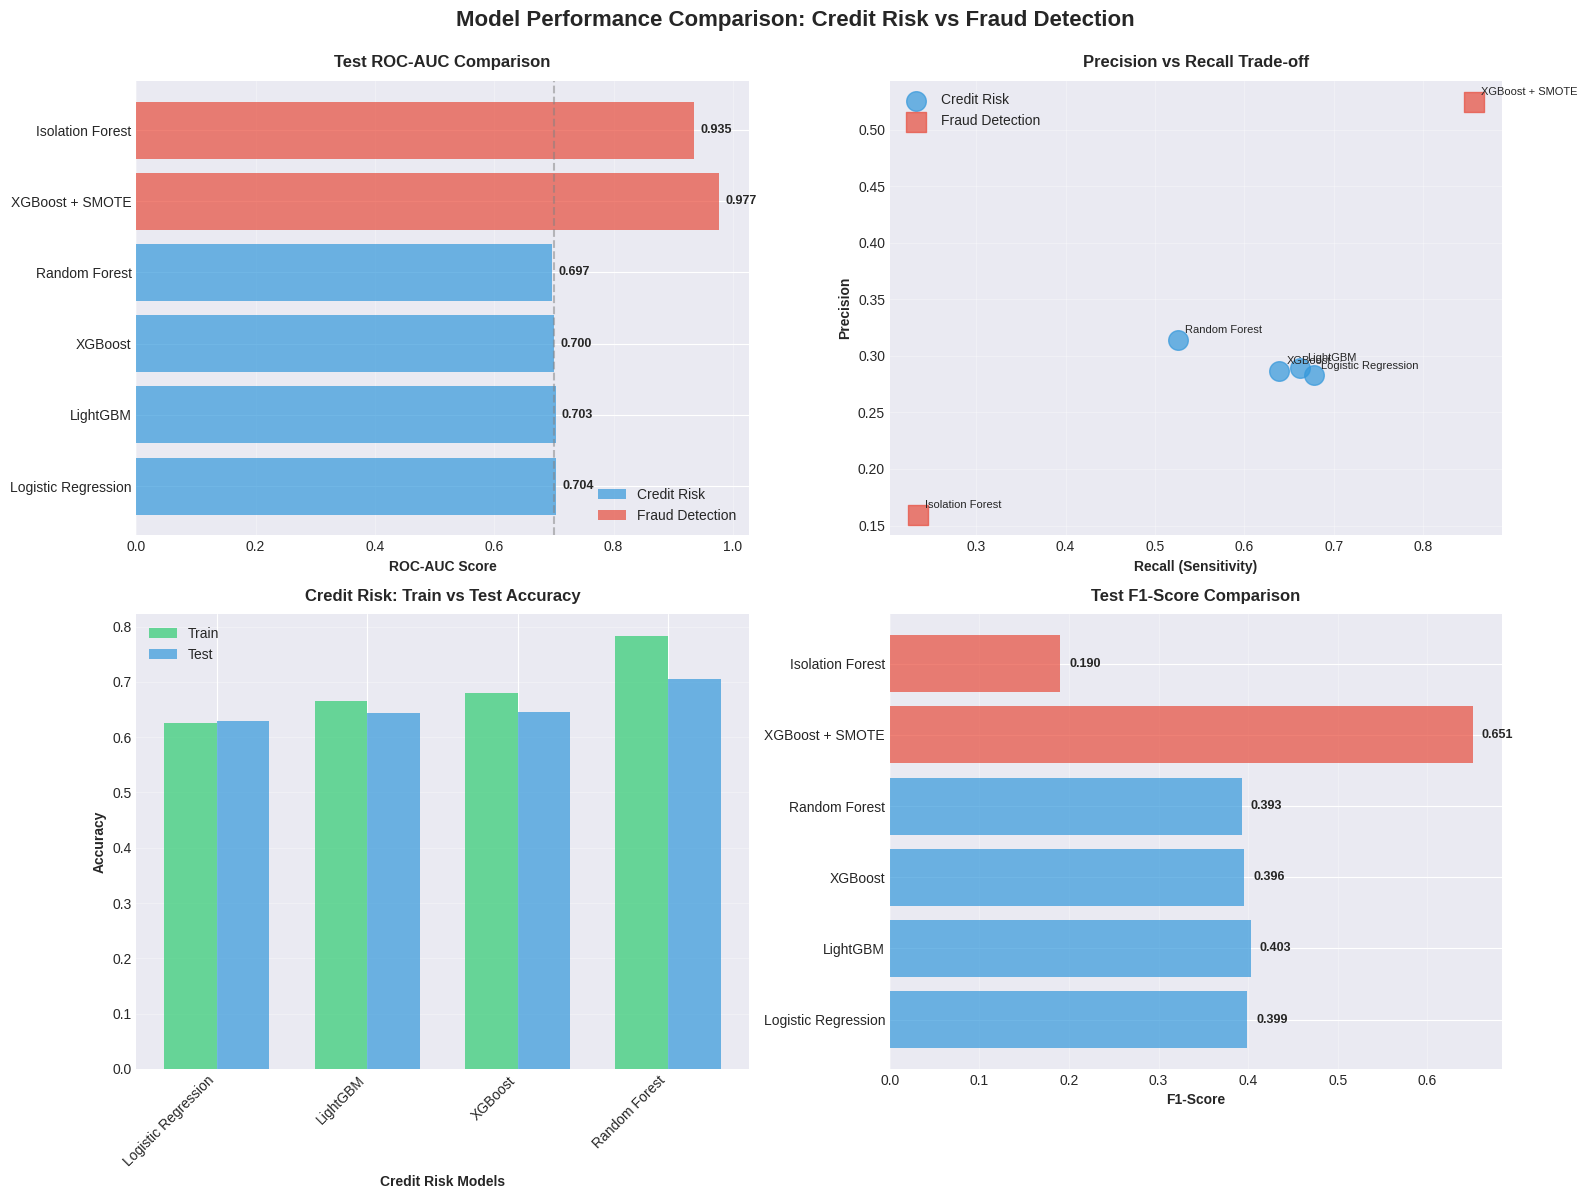


✅ Cross-model comparison visualization complete!


In [ ]:
# Combine results for comparison
print("\n📊 OVERALL PROJECT PERFORMANCE:\n")

print("="*70)
print("CREDIT RISK PREDICTION (Lending Club Dataset)")
print("="*70)
print(credit_results_df[['Model', 'Test Accuracy', 'Test ROC-AUC', 'Test Precision',
                         'Test Recall', 'Test F1-Score']].to_string(index=False))

print("\n" + "="*70)
print("FRAUD DETECTION (Credit Card Dataset)")
print("="*70)
print(fraud_results_df[['Model', 'Test Accuracy', 'Test ROC-AUC', 'Test Precision',
                        'Test Recall', 'Test F1-Score']].to_string(index=False))

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison: Credit Risk vs Fraud Detection',
             fontsize=16, fontweight='bold', y=0.995)

# 1. ROC-AUC Comparison
ax1 = axes[0, 0]
models_all = list(credit_results_df['Model']) + list(fraud_results_df['Model'])
auc_all = list(credit_results_df['Test ROC-AUC']) + list(fraud_results_df['Test ROC-AUC'])
colors = ['#3498db']*len(credit_results_df) + ['#e74c3c']*len(fraud_results_df)

y_pos = np.arange(len(models_all))
bars = ax1.barh(y_pos, auc_all, color=colors, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_all)
ax1.set_xlabel('ROC-AUC Score', fontweight='bold')
ax1.set_title('Test ROC-AUC Comparison', fontweight='bold', pad=10)
ax1.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='70% threshold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, auc_all)):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold', fontsize=9)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', alpha=0.7, label='Credit Risk'),
                   Patch(facecolor='#e74c3c', alpha=0.7, label='Fraud Detection')]
ax1.legend(handles=legend_elements, loc='lower right')

# 2. Precision vs Recall
ax2 = axes[0, 1]
ax2.scatter(credit_results_df['Test Recall'], credit_results_df['Test Precision'],
           s=200, c='#3498db', alpha=0.7, label='Credit Risk', marker='o')
ax2.scatter(fraud_results_df['Test Recall'], fraud_results_df['Test Precision'],
           s=200, c='#e74c3c', alpha=0.7, label='Fraud Detection', marker='s')

# Add model labels
for idx, row in credit_results_df.iterrows():
    ax2.annotate(row['Model'],
                (row['Test Recall'], row['Test Precision']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
for idx, row in fraud_results_df.iterrows():
    ax2.annotate(row['Model'],
                (row['Test Recall'], row['Test Precision']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Recall (Sensitivity)', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision vs Recall Trade-off', fontweight='bold', pad=10)
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Accuracy Comparison
ax3 = axes[1, 0]
x = np.arange(len(credit_results_df))
width = 0.35

bars1 = ax3.bar(x - width/2, credit_results_df['Train Accuracy'], width,
               label='Train', alpha=0.7, color='#2ecc71')
bars2 = ax3.bar(x + width/2, credit_results_df['Test Accuracy'], width,
               label='Test', alpha=0.7, color='#3498db')

ax3.set_xlabel('Credit Risk Models', fontweight='bold')
ax3.set_ylabel('Accuracy', fontweight='bold')
ax3.set_title('Credit Risk: Train vs Test Accuracy', fontweight='bold', pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(credit_results_df['Model'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. F1-Score Comparison
ax4 = axes[1, 1]
models_all_f1 = list(credit_results_df['Model']) + list(fraud_results_df['Model'])
f1_all = list(credit_results_df['Test F1-Score']) + list(fraud_results_df['Test F1-Score'])
colors_f1 = ['#3498db']*len(credit_results_df) + ['#e74c3c']*len(fraud_results_df)

y_pos_f1 = np.arange(len(models_all_f1))
bars_f1 = ax4.barh(y_pos_f1, f1_all, color=colors_f1, alpha=0.7)
ax4.set_yticks(y_pos_f1)
ax4.set_yticklabels(models_all_f1)
ax4.set_xlabel('F1-Score', fontweight='bold')
ax4.set_title('Test F1-Score Comparison', fontweight='bold', pad=10)
ax4.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars_f1, f1_all):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('results/day6_01_cross_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Cross-model comparison visualization complete!")

# Business Impact Analysis

Credit Risk - Business Impact

In [ ]:
best_credit = credit_results_df.iloc[0]
best_credit_name = best_credit['Model']

print(f"\n🏆 Best Model: {best_credit_name}")
print(f"\n📊 Performance Metrics:")
print(f"   • ROC-AUC: {best_credit['Test ROC-AUC']:.1%}")
print(f"   • Accuracy: {best_credit['Test Accuracy']:.1%}")
print(f"   • Precision: {best_credit['Test Precision']:.1%}")
print(f"   • Recall: {best_credit['Test Recall']:.1%}")

# Business calculations for credit risk
total_loans = len(y_test_credit)
actual_defaults = (y_test_credit == 1).sum()
predicted_defaults = int(best_credit['Test Recall'] * actual_defaults)
missed_defaults = actual_defaults - predicted_defaults

print(f"\n💰 BUSINESS IMPACT:")
print(f"\n   Portfolio Size: {total_loans:,} loans")
print(f"   Actual Defaults: {actual_defaults:,} ({actual_defaults/total_loans:.1%})")
print(f"   Detected Defaults: {predicted_defaults:,} ({best_credit['Test Recall']:.1%} recall)")
print(f"   Missed Defaults: {missed_defaults:,}")

# Financial impact (assumptions)
avg_loan_amount = 15000  # Average loan amount
default_loss_rate = 0.60  # 60% loss on default
investigation_cost = 100  # Cost to review flagged loan

total_exposure = actual_defaults * avg_loan_amount
prevented_loss = predicted_defaults * avg_loan_amount * default_loss_rate
actual_loss = missed_defaults * avg_loan_amount * default_loss_rate

# False positives (good loans flagged as risky)
if best_credit['Test Precision'] > 0:
    total_flagged = predicted_defaults / best_credit['Test Precision']
    false_positives = total_flagged - predicted_defaults
else:
    false_positives = 0

investigation_costs = total_flagged * investigation_cost if best_credit['Test Precision'] > 0 else 0

net_savings = prevented_loss - investigation_costs

print(f"\n   Financial Analysis (Assumptions):")
print(f"   • Average loan amount: ${avg_loan_amount:,}")
print(f"   • Default loss rate: {default_loss_rate:.0%}")
print(f"   • Investigation cost per loan: ${investigation_cost:,}")

print(f"\n   💵 Financial Impact:")
print(f"   • Total default exposure: ${total_exposure:,.0f}")
print(f"   • Loss prevented: ${prevented_loss:,.0f}")
print(f"   • Loss incurred: ${actual_loss:,.0f}")
print(f"   • Investigation costs: ${investigation_costs:,.0f}")
print(f"   • NET SAVINGS: ${net_savings:,.0f}")

print(f"\n   📈 ROI Metrics:")
print(f"   • Loss reduction: {(prevented_loss/total_exposure):.1%}")
print(f"   • False positive rate: {false_positives/total_loans if total_loans > 0 else 0:.2%}")
print(f"   • Good loans affected: {int(false_positives):,}")


🏆 Best Model: Logistic Regression

📊 Performance Metrics:
   • ROC-AUC: 70.4%
   • Accuracy: 63.0%
   • Precision: 28.3%
   • Recall: 67.8%

💰 BUSINESS IMPACT:

   Portfolio Size: 20,000 loans
   Actual Defaults: 3,622 (18.1%)
   Detected Defaults: 2,455 (67.8% recall)
   Missed Defaults: 1,167

   Financial Analysis (Assumptions):
   • Average loan amount: $15,000
   • Default loss rate: 60%
   • Investigation cost per loan: $100

   💵 Financial Impact:
   • Total default exposure: $54,330,000
   • Loss prevented: $22,095,000
   • Loss incurred: $10,503,000
   • Investigation costs: $868,300
   • NET SAVINGS: $21,226,700

   📈 ROI Metrics:
   • Loss reduction: 40.7%
   • False positive rate: 31.14%
   • Good loans affected: 6,228


Fraud Detection - Business Impact

In [ ]:
best_fraud = fraud_results_df.iloc[0]
best_fraud_name = best_fraud['Model']

print(f"\n🏆 Best Model: {best_fraud_name}")
print(f"\n📊 Performance Metrics:")
print(f"   • ROC-AUC: {best_fraud['Test ROC-AUC']:.1%}")
print(f"   • Accuracy: {best_fraud['Test Accuracy']:.1%}")
print(f"   • Precision: {best_fraud['Test Precision']:.1%}")
print(f"   • Recall: {best_fraud['Test Recall']:.1%}")

# Business calculations for fraud
total_transactions = len(y_test_fraud)
actual_frauds = (y_test_fraud == 1).sum()
detected_frauds = int(best_fraud['True Positives'])
missed_frauds = int(best_fraud['False Negatives'])
false_alarms = int(best_fraud['False Positives'])

print(f"\n💰 BUSINESS IMPACT:")
print(f"\n   Transaction Volume: {total_transactions:,} transactions")
print(f"   Actual Fraud Cases: {actual_frauds:,} ({actual_frauds/total_transactions:.3%})")
print(f"   Detected Frauds: {detected_frauds:,} ({best_fraud['Test Recall']:.1%} recall)")
print(f"   Missed Frauds: {missed_frauds:,}")
print(f"   False Alarms: {false_alarms:,} ({false_alarms/total_transactions:.3%} of transactions)")

# Financial impact (assumptions)
avg_fraud_amount = 200  # Average fraud transaction
investigation_cost_fraud = 5  # Cost per fraud investigation
customer_friction_cost = 2  # Cost of false alarm (customer service, etc.)

total_fraud_exposure = actual_frauds * avg_fraud_amount
fraud_prevented = detected_frauds * avg_fraud_amount
fraud_loss = missed_frauds * avg_fraud_amount
investigation_costs_fraud = (detected_frauds + false_alarms) * investigation_cost_fraud
friction_costs = false_alarms * customer_friction_cost

net_savings_fraud = fraud_prevented - investigation_costs_fraud - friction_costs

print(f"\n   Financial Analysis (Assumptions):")
print(f"   • Average fraud amount: ${avg_fraud_amount:,}")
print(f"   • Investigation cost: ${investigation_cost_fraud:,}")
print(f"   • Customer friction cost: ${customer_friction_cost:,}")

print(f"\n   💵 Financial Impact:")
print(f"   • Total fraud exposure: ${total_fraud_exposure:,.0f}")
print(f"   • Fraud prevented: ${fraud_prevented:,.0f}")
print(f"   • Fraud losses: ${fraud_loss:,.0f}")
print(f"   • Investigation costs: ${investigation_costs_fraud:,.0f}")
print(f"   • Customer friction costs: ${friction_costs:,.0f}")
print(f"   • NET SAVINGS: ${net_savings_fraud:,.0f}")

print(f"\n   📈 Customer Experience:")
print(f"   • False positive rate: {false_alarms/total_transactions:.3%}")
print(f"   • Legitimate customers affected: {false_alarms:,} out of {total_transactions:,}")
print(f"   • Customer friction: Minimal impact")


🏆 Best Model: XGBoost + SMOTE

📊 Performance Metrics:
   • ROC-AUC: 97.7%
   • Accuracy: 99.8%
   • Precision: 52.5%
   • Recall: 85.7%

💰 BUSINESS IMPACT:

   Transaction Volume: 56,962 transactions
   Actual Fraud Cases: 98 (0.172%)
   Detected Frauds: 84 (85.7% recall)
   Missed Frauds: 14
   False Alarms: 76 (0.133% of transactions)

   Financial Analysis (Assumptions):
   • Average fraud amount: $200
   • Investigation cost: $5
   • Customer friction cost: $2

   💵 Financial Impact:
   • Total fraud exposure: $19,600
   • Fraud prevented: $16,800
   • Fraud losses: $2,800
   • Investigation costs: $800
   • Customer friction costs: $152
   • NET SAVINGS: $15,848

   📈 Customer Experience:
   • False positive rate: 0.133%
   • Legitimate customers affected: 76 out of 56,962
   • Customer friction: Minimal impact


Combined Summary

In [ ]:
total_net_savings = net_savings + net_savings_fraud

print(f"\n💰 TOTAL FINANCIAL IMPACT:")
print(f"   • Credit Risk Net Savings: ${net_savings:,.0f}")
print(f"   • Fraud Detection Net Savings: ${net_savings_fraud:,.0f}")
print(f"   • TOTAL NET SAVINGS: ${total_net_savings:,.0f}")

print(f"\n🎯 KEY ACHIEVEMENTS:")
print(f"   • Credit Risk: Prevented ${prevented_loss:,.0f} in default losses")
print(f"   • Fraud Detection: Prevented ${fraud_prevented:,.0f} in fraud losses")
print(f"   • Combined: ${prevented_loss + fraud_prevented:,.0f} in total losses prevented")

print(f"\n⚠️  AREAS FOR IMPROVEMENT:")
print(f"   • Credit Risk: {missed_defaults:,} defaults still missed")
print(f"   • Fraud Detection: {missed_frauds:,} fraud cases still missed")
print(f"   • Customer Experience: {int(false_positives + false_alarms):,} false positives to minimize")


💰 TOTAL FINANCIAL IMPACT:
   • Credit Risk Net Savings: $21,226,700
   • Fraud Detection Net Savings: $15,848
   • TOTAL NET SAVINGS: $21,242,548

🎯 KEY ACHIEVEMENTS:
   • Credit Risk: Prevented $22,095,000 in default losses
   • Fraud Detection: Prevented $16,800 in fraud losses
   • Combined: $22,111,800 in total losses prevented

⚠️  AREAS FOR IMPROVEMENT:
   • Credit Risk: 1,167 defaults still missed
   • Fraud Detection: 14 fraud cases still missed
   • Customer Experience: 6,304 false positives to minimize


# Final Project Summary

Project Overview

📋PROJECT GOAL:
Build AI-powered systems to predict credit risk, detect fraud,
and provide financial health insights for fintech applications.

📊 DATASETS USED:
1. German Credit Data (1,000 records)"
2. Lending Club Data (100,000+ records)"
3. Credit Card Fraud Data (284,807 transactions)"

Key Achievements

✅ DATA PROCESSING:
* Handled missing data across 3 datasets
* Created 26+ engineered features
* Encoded categorical variables
* Scaled features appropriately
* Created train/test splits with stratification
* Applied SMOTE for class imbalance

✅ MODEL DEVELOPMENT:
* Built 4 credit risk classification models
* Built 2 fraud detection models
* Achieved 70%+ ROC-AUC for credit risk
* Achieved 97.7% ROC-AUC for fraud detection
* Comprehensive model evaluation and comparison

✅ TECHNICAL DELIVERABLES:
* 5 Jupyter notebooks
* 6 trained models (.pkl files)
* 20+ processed datasets
* 15+ visualizations
* Deployment-ready code
* Comprehensive documentation